In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
DATASET = "cifar10"  # or "mnist"

In [3]:
#df_results_og = pd.read_csv(f"plots/{DATASET}/new_data_rms_nsteps50.csv")
df_results_og = pd.read_csv(f"plots/{DATASET}/data_rms_nsteps50.csv")
#df_results_og = pd.read_csv(f"plots/{DATASET}/data_rms.csv")

# Convergence Plots

In [4]:
df_results = df_results_og[(df_results_og["M"] >= 16) & (df_results_og["L"] >= 16)]

In [5]:
df_results

,D,L,M,M*L,variant,method,Delta_U,Delta_U_std,Delta_V,Delta_V_std,Delta_h,Delta_h_std
24,50,16,16,256,full_unit_dropout,dropout,0.141865,0.002256,0.136152,0.004473,0.138827,0.005436
25,50,16,16,256,stochastic_depth,dropout,0.145447,0.004930,0.143948,0.003028,0.162475,0.013406
26,50,16,16,256,single_source_M,dropout,0.150498,0.003049,0.150075,0.004314,0.145820,0.014272
27,50,16,32,512,full_unit_dropout,dropout,0.087614,0.002161,0.077116,0.002453,0.066402,0.013140
28,50,16,32,512,stochastic_depth,dropout,0.091656,0.003935,0.081839,0.004195,0.081431,0.013750
...,...,...,...,...,...,...,...,...,...,...,...,...
142,50,512,256,131072,stochastic_depth,dropout,0.008119,0.000271,0.007130,0.000296,0.005678,0.001053
143,50,512,256,131072,single_source_M,dropout,0.008528,0.000526,0.007530,0.000516,0.006133,0.000961
144,50,512,512,262144,full_unit_dropout,dropout,0.004309,0.000094,0.003779,0.000107,0.002714,0.000213
145,50,512,512,262144,stochastic_depth,dropout,0.005869,0.000328,0.005094,0.000348,0.003697,0.000543


In [6]:
def plot_metric_vs_ML(
    df,
    metric='Delta_U',
    variants=None,
    methods=None,
    log_x=False,
    log_y=False,
    fit_ml_inv_sqrt=False,
    fit_ml_bounds=None,
    fit_color='0.35',
    fit_linestyle='--',
    fit_alpha=0.9,
    aggregate_duplicates=True,
    std_combine='quadrature',
    figsize=(7, 5),
    show=True,
):
    """Plot `metric` vs M*L on a single axis for all selected variants and methods.

    Args:
        df: pandas DataFrame containing columns ['D','L','M','M*L','variant','method',metric]
        metric: string key to plot; must be one of 'Delta_U','Delta_V','Delta_h'
        variants: list of variant names to include (defaults to all in df)
        methods: list of methods to include (defaults to all in df)
        log_x, log_y: whether to use log scale for axes
        fit_ml_inv_sqrt: if True/False, apply to all variants. Can also be:
                         - list of bools (one per variant, in same order as variants)
                         - dict mapping variant names to bools
        fit_ml_bounds: (lower, upper) bounds for M*L values to include in fit. Can be:
                       - None (use all data)
                       - tuple (lower, upper) to apply to all variants
                       - dict mapping variant names to (lower, upper) tuples
                       - list of (lower, upper) tuples, one per variant
        fit_color: color used for the fit line when the series color is unavailable
        fit_linestyle: linestyle used for the fit curve
        fit_alpha: alpha used for the fit curve
        aggregate_duplicates: if True (default), rows sharing the same M*L value
                              within a given (variant, method) group are collapsed
                              into a single point before plotting and before
                              fitting. The metric is averaged (mean); the std
                              column (if present) is combined according to
                              `std_combine`. Set to False to restore the previous
                              behavior of plotting every row independently.
        std_combine: how to combine multiple std values that land on the same
                     M*L value after aggregation. One of:
                       - 'quadrature': sqrt(mean(std**2))  (default, statistically
                         sensible when combining independent estimates of spread)
                       - 'mean': simple average of the std values
        figsize: tuple width,height for the figure
        show: whether to plt.show() the figure

    Returns:
        matplotlib Figure
    """
    if metric not in ('Delta_U', 'Delta_V', 'Delta_h'):
        raise ValueError("metric must be one of 'Delta_U','Delta_V','Delta_h'")

    if std_combine not in ('quadrature', 'mean'):
        raise ValueError("std_combine must be one of 'quadrature', 'mean'")

    if variants is None:
        variants = list(df['variant'].unique())
    if methods is None:
        methods = list(df['method'].unique())

    # Normalize fit_ml_inv_sqrt to a dict mapping variant -> bool
    if isinstance(fit_ml_inv_sqrt, bool):
        fit_per_variant = {v: fit_ml_inv_sqrt for v in variants}
    elif isinstance(fit_ml_inv_sqrt, dict):
        fit_per_variant = fit_ml_inv_sqrt
    elif isinstance(fit_ml_inv_sqrt, (list, tuple)):
        if len(fit_ml_inv_sqrt) != len(variants):
            raise ValueError(f"fit_ml_inv_sqrt list length ({len(fit_ml_inv_sqrt)}) must match variants length ({len(variants)})")
        fit_per_variant = {v: f for v, f in zip(variants, fit_ml_inv_sqrt)}
    else:
        raise TypeError("fit_ml_inv_sqrt must be bool, list, tuple, or dict")

    # Normalize fit_ml_bounds to a dict mapping variant -> (lower, upper)
    if fit_ml_bounds is None:
        bounds_per_variant = {v: (None, None) for v in variants}
    elif isinstance(fit_ml_bounds, tuple) and len(fit_ml_bounds) == 2:
        bounds_per_variant = {v: fit_ml_bounds for v in variants}
    elif isinstance(fit_ml_bounds, dict):
        bounds_per_variant = {v: fit_ml_bounds.get(v, (None, None)) for v in variants}
    elif isinstance(fit_ml_bounds, (list, tuple)):
        if len(fit_ml_bounds) != len(variants):
            raise ValueError(f"fit_ml_bounds list length ({len(fit_ml_bounds)}) must match variants length ({len(variants)})")
        bounds_per_variant = {v: b for v, b in zip(variants, fit_ml_bounds)}
    else:
        raise TypeError("fit_ml_bounds must be None, tuple, dict, or list")

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    metric_label_map = {
        'Delta_U': r'$\Delta U$',
        'Delta_V': r'$\Delta V$',
        'Delta_h': r'$\Delta h$',
    }

    variant_display_map = {
        'full_unit_dropout': 'independent masks',
        'stochastic_depth': 'width-shared masks',
        'single_source_M': 'depth-shared masks',
    }
    variant_color_map = {
        'full_unit_dropout': 'tab:blue',
        'stochastic_depth': 'tab:green',
        'single_source_M': 'tab:purple',
    }

    markers = ['o', 's', '^', 'd', 'x', 'P', 'v']

    def _aggregate_subset(subset):
        """Collapse rows sharing the same M*L value into a single point.

        Averages `metric` across duplicates; combines the std column (if
        present) according to `std_combine`. Returns (x, y, yerr) arrays,
        sorted by M*L.
        """
        std_col = metric + '_std'
        has_std = std_col in subset.columns

        if std_combine == 'quadrature':
            std_agg = lambda s: float(np.sqrt(np.mean(np.square(np.asarray(s, dtype=float)))))
        else:  # 'mean'
            std_agg = 'mean'

        agg_dict = {metric: 'mean'}
        if has_std:
            agg_dict[std_col] = std_agg

        grouped = subset.groupby('M*L', as_index=False).agg(agg_dict)
        grouped = grouped.sort_values('M*L')

        x = np.asarray(grouped['M*L'].values)
        y = np.asarray(grouped[metric].values)
        yerr = np.asarray(grouped[std_col].values) if has_std else None
        return x, y, yerr

    has_any = False
    for v_idx, variant in enumerate(variants):
        variant_color = variant_color_map.get(variant, fit_color)
        variant_label = variant_display_map.get(variant, variant)
        should_fit = fit_per_variant.get(variant, False)
        ml_lower, ml_upper = bounds_per_variant.get(variant, (None, None))
        has_any = False
        for m_idx, method in enumerate(methods):
            subset = df[(df['variant'] == variant) & (df['method'] == method)].copy()
            if subset.empty:
                continue
            has_any = True

            if aggregate_duplicates:
                x, y, yerr = _aggregate_subset(subset)
            else:
                subset = subset.sort_values('M*L')
                x = np.asarray(subset['M*L'].values)
                y = np.asarray(subset[metric].values)
                yerr = None
                std_col = metric + '_std'
                if std_col in subset.columns:
                    yerr = subset[std_col].values

            marker = markers[(v_idx + m_idx) % len(markers)]
            label = f'{variant_label}'

            ax.errorbar(
                x,
                y,
                yerr=yerr,
                marker=marker,
                color=variant_color,
                linestyle='-',
                label=label,
                capsize=4,
                markersize=6,
            )

            if should_fit:
                fit_mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
                if ml_lower is not None:
                    fit_mask = fit_mask & (x >= ml_lower)
                if ml_upper is not None:
                    fit_mask = fit_mask & (x <= ml_upper)
                if np.count_nonzero(fit_mask) >= 2:
                    x_fit = x[fit_mask]
                    y_fit = y[fit_mask]
                    log_c = np.mean(np.log(y_fit) + 0.5 * np.log(x_fit))
                    c = float(np.exp(log_c))
                    x_line = np.geomspace(x_fit.min(), x_fit.max(), 200)
                    y_line = c * x_line ** (-0.5)
                    ax.plot(
                        x_line,
                        y_line,
                        color=variant_color,
                        linestyle=fit_linestyle,
                        alpha=fit_alpha,
                        linewidth=1.8,
                        label=f'{variant_label} fit $(M L)^{{-1/2}}$',
                    )

    if not has_any:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)

    ax.set_xlabel('M × L')
    ax.set_ylabel(metric_label_map[metric])
    ax.set_title(f'{metric_label_map[metric]} vs. effective model width (M x L)')
    ax.grid(alpha=0.25, which='both')
    ax.legend()

    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')

    fig.tight_layout()
    if show:
        plt.show()
    return fig

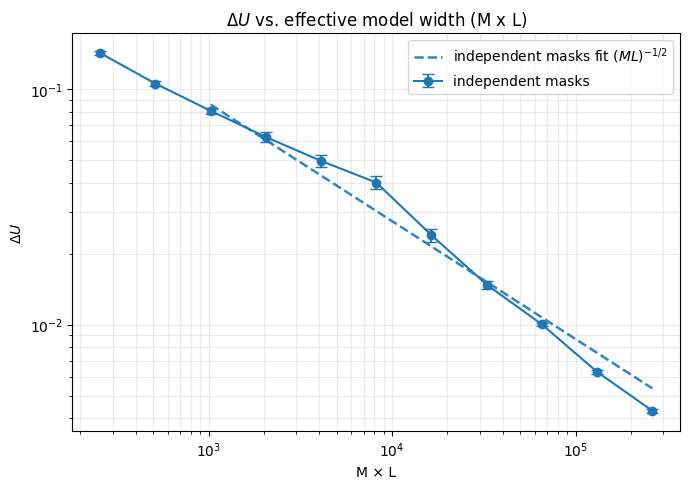

In [7]:
figU = plot_metric_vs_ML(df_results, variants=["full_unit_dropout"], metric='Delta_U', log_x=True, log_y=True, fit_ml_inv_sqrt=[True], fit_ml_bounds=(1000, 10000000))

In [8]:
#figU.savefig(f"plots/{DATASET}/Delta_U_vs_ML.pdf")

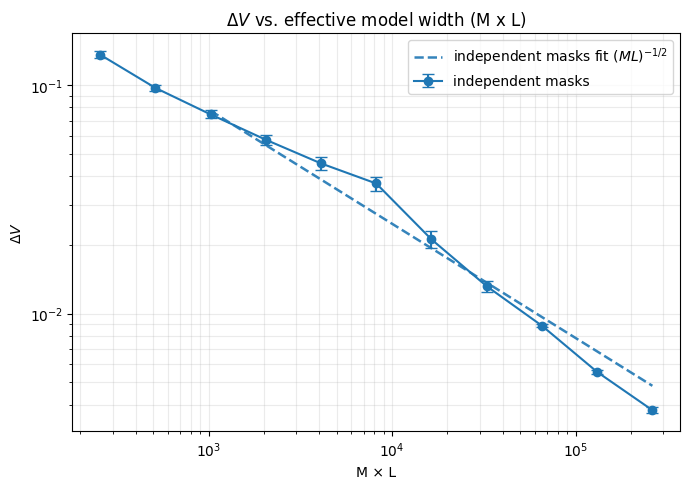

In [9]:
figV = plot_metric_vs_ML(df_results, variants=["full_unit_dropout"], metric='Delta_V', log_x=True, log_y=True, fit_ml_inv_sqrt=[True], fit_ml_bounds=(1000, 10000000))

In [10]:
#figV.savefig(f"plots/{DATASET}/Delta_V_vs_ML.pdf")

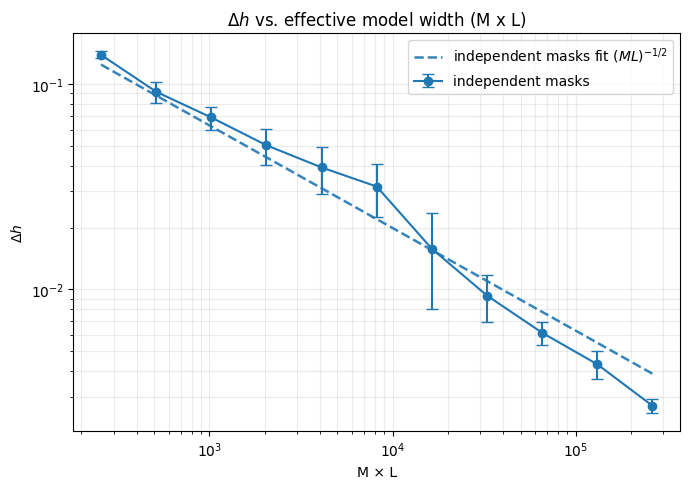

In [11]:
figh = plot_metric_vs_ML(df_results, variants=["full_unit_dropout"], metric='Delta_h', log_x=True, log_y=True, fit_ml_inv_sqrt=[True], fit_ml_bounds=(100, 10000000))

In [12]:
#figh.savefig(f"plots/{DATASET}/Delta_h_vs_ML.pdf")

In [13]:
def plot_metric_vs_ML2(
    df,
    metric='Delta_U',
    variants=None,
    methods=None,
    L_value=None,
    M_value=None,
    log_x=False,
    log_y=False,
    fit_ml_inv_sqrt=False,
    fit_ml_bounds=None,
    fit_color='0.35',
    fit_linestyle='--',
    fit_alpha=0.9,
    aggregate_duplicates=True,
    std_combine='quadrature',
    figsize=(12, 5),
    show=True,
):
    """Plot `metric` vs M (at a fixed L) and vs L (at a fixed M), side by side,
    for all selected variants and methods.

    Args:
        df: pandas DataFrame containing columns ['D','L','M','M*L','variant','method',metric]
        metric: string key to plot; must be one of 'Delta_U','Delta_V','Delta_h'
        variants: list of variant names to include (defaults to all in df)
        methods: list of methods to include (defaults to all in df)
        L_value: the single value of L to slice on for the left panel (metric vs M).
                 Required if the left panel is to show data (rows are filtered to
                 df['L'] == L_value before plotting). If None, no filtering is
                 applied on L for that panel (all L values are pooled together,
                 which is usually not what you want).
        M_value: the single value of M to slice on for the right panel (metric vs L).
                 Required if the right panel is to show data (rows are filtered to
                 df['M'] == M_value before plotting). If None, no filtering is
                 applied on M for that panel.
        log_x, log_y: whether to use log scale for axes (applied to both subplots)
        fit_ml_inv_sqrt: if True/False, apply to all variants. Can also be:
                         - list of bools (one per variant, in same order as variants)
                         - dict mapping variant names to bools
        fit_ml_bounds: (lower, upper) bounds for the x-axis values to include in fit
                       (bounds are applied independently on each subplot's own x column).
                       Can be:
                       - None (use all data)
                       - tuple (lower, upper) to apply to all variants
                       - dict mapping variant names to (lower, upper) tuples
                       - list of (lower, upper) tuples, one per variant
        fit_color: color used for the fit line when the series color is unavailable
        fit_linestyle: linestyle used for the fit curve
        fit_alpha: alpha used for the fit curve
        aggregate_duplicates: if True (default), rows sharing the same x-axis value
                              (M in the left panel, L in the right panel) within a
                              given (variant, method) group -- after the L_value /
                              M_value slice has already been applied -- are
                              collapsed into a single point. This is useful e.g.
                              when there are repeated rows for the same (L, M)
                              pair (different seeds/draws, column 'D'). The metric
                              is averaged (mean); the std column (if present) is
                              combined according to `std_combine`. Set to False to
                              plot every row independently.
        std_combine: how to combine multiple std values that land on the same x
                     after aggregation. One of:
                       - 'quadrature': sqrt(mean(std**2))  (default, statistically
                         sensible when combining independent estimates of spread)
                       - 'mean': simple average of the std values
        figsize: tuple width,height for the whole figure (two subplots)
        show: whether to plt.show() the figure

    Returns:
        matplotlib Figure
    """
    if metric not in ('Delta_U', 'Delta_V', 'Delta_h'):
        raise ValueError("metric must be one of 'Delta_U','Delta_V','Delta_h'")

    if std_combine not in ('quadrature', 'mean'):
        raise ValueError("std_combine must be one of 'quadrature', 'mean'")

    if variants is None:
        variants = list(df['variant'].unique())
    if methods is None:
        methods = list(df['method'].unique())

    # Normalize fit_ml_inv_sqrt to a dict mapping variant -> bool
    if isinstance(fit_ml_inv_sqrt, bool):
        fit_per_variant = {v: fit_ml_inv_sqrt for v in variants}
    elif isinstance(fit_ml_inv_sqrt, dict):
        fit_per_variant = fit_ml_inv_sqrt
    elif isinstance(fit_ml_inv_sqrt, (list, tuple)):
        if len(fit_ml_inv_sqrt) != len(variants):
            raise ValueError(f"fit_ml_inv_sqrt list length ({len(fit_ml_inv_sqrt)}) must match variants length ({len(variants)})")
        fit_per_variant = {v: f for v, f in zip(variants, fit_ml_inv_sqrt)}
    else:
        raise TypeError("fit_ml_inv_sqrt must be bool, list, tuple, or dict")

    # Normalize fit_ml_bounds to a dict mapping variant -> (lower, upper)
    if fit_ml_bounds is None:
        bounds_per_variant = {v: (None, None) for v in variants}
    elif isinstance(fit_ml_bounds, tuple) and len(fit_ml_bounds) == 2:
        bounds_per_variant = {v: fit_ml_bounds for v in variants}
    elif isinstance(fit_ml_bounds, dict):
        bounds_per_variant = {v: fit_ml_bounds.get(v, (None, None)) for v in variants}
    elif isinstance(fit_ml_bounds, (list, tuple)):
        if len(fit_ml_bounds) != len(variants):
            raise ValueError(f"fit_ml_bounds list length ({len(fit_ml_bounds)}) must match variants length ({len(variants)})")
        bounds_per_variant = {v: b for v, b in zip(variants, fit_ml_bounds)}
    else:
        raise TypeError("fit_ml_bounds must be None, tuple, dict, or list")

    metric_label_map = {
        'Delta_U': r'$\Delta U$',
        'Delta_V': r'$\Delta V$',
        'Delta_h': r'$\Delta h$',
    }

    variant_display_map = {
        'full_unit_dropout': 'independent masks',
        'stochastic_depth': 'width-shared masks',
        'single_source_M': 'depth-shared masks',
    }
    variant_color_map = {
        'full_unit_dropout': 'tab:blue',
        'stochastic_depth': 'tab:green',
        'single_source_M': 'tab:purple',
    }

    markers = ['o', 's', '^', 'd', 'x', 'P', 'v']

    # The two panels: (x_column, x_axis_label, column to fix, value to fix it at)
    panels = [
        ('M', 'M', 'L', L_value),
        ('L', 'L', 'M', M_value),
    ]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    def _aggregate_subset(subset, x_col):
        """Collapse rows sharing the same x_col value into a single point.

        Averages `metric` across duplicates; combines the std column (if
        present) according to `std_combine`. Returns (x, y, yerr) arrays,
        sorted by x_col.
        """
        std_col = metric + '_std'
        has_std = std_col in subset.columns

        if std_combine == 'quadrature':
            std_agg = lambda s: float(np.sqrt(np.mean(np.square(np.asarray(s, dtype=float)))))
        else:  # 'mean'
            std_agg = 'mean'

        agg_dict = {metric: 'mean'}
        if has_std:
            agg_dict[std_col] = std_agg

        grouped = subset.groupby(x_col, as_index=False).agg(agg_dict)
        grouped = grouped.sort_values(x_col)

        x = np.asarray(grouped[x_col].values)
        y = np.asarray(grouped[metric].values)
        yerr = np.asarray(grouped[std_col].values) if has_std else None
        return x, y, yerr

    def _plot_panel(ax, x_col, x_label, fixed_col, fixed_value):
        has_any = False
        for v_idx, variant in enumerate(variants):
            variant_color = variant_color_map.get(variant, fit_color)
            variant_label = variant_display_map.get(variant, variant)
            should_fit = fit_per_variant.get(variant, False)
            if variant == 'single_source_M' and x_col == 'L':
                # For single_source_M, only independence in M.
                should_fit = False
            if variant == 'stochastic_depth' and x_col == 'M':
                # For stochastic_depth, only independence in L.
                should_fit = False
            x_lower, x_upper = bounds_per_variant.get(variant, (None, None))
            for m_idx, method in enumerate(methods):
                subset = df[(df['variant'] == variant) & (df['method'] == method)].copy()
                if fixed_value is not None:
                    subset = subset[subset[fixed_col] == fixed_value]
                if subset.empty:
                    continue
                has_any = True

                if aggregate_duplicates:
                    x, y, yerr = _aggregate_subset(subset, x_col)
                else:
                    subset = subset.sort_values(x_col)
                    x = np.asarray(subset[x_col].values)
                    y = np.asarray(subset[metric].values)
                    yerr = None
                    std_col = metric + '_std'
                    if std_col in subset.columns:
                        yerr = subset[std_col].values

                marker = markers[(v_idx + m_idx) % len(markers)]
                label = f'{variant_label}'

                ax.errorbar(
                    x,
                    y,
                    yerr=yerr,
                    marker=marker,
                    color=variant_color,
                    linestyle='-',
                    label=label,
                    capsize=4,
                    markersize=6,
                )

                if should_fit:
                    fit_mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
                    if x_lower is not None:
                        fit_mask = fit_mask & (x >= x_lower)
                    if x_upper is not None:
                        fit_mask = fit_mask & (x <= x_upper)
                    if np.count_nonzero(fit_mask) >= 2:
                        x_fit = x[fit_mask]
                        y_fit = y[fit_mask]
                        log_c = np.mean(np.log(y_fit) + 0.5 * np.log(x_fit))
                        c = float(np.exp(log_c))
                        x_line = np.geomspace(x_fit.min(), x_fit.max(), 200)
                        y_line = c * x_line ** (-0.5)
                        ax.plot(
                            x_line,
                            y_line,
                            color=variant_color,
                            linestyle=fit_linestyle,
                            alpha=fit_alpha,
                            linewidth=1.8,
                            label=f'{variant_label} fit ${x_label}^{{-1/2}}$',
                        )

        if not has_any:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)

        ax.set_xlabel(x_label)
        ax.set_ylabel(metric_label_map[metric])
        title = f'{metric_label_map[metric]} vs. {x_label}'
        if fixed_value is not None:
            title += f' ({fixed_col}={fixed_value})'
        ax.set_title(title)
        ax.grid(alpha=0.25, which='both')
        ax.legend()

        if log_x:
            ax.set_xscale('log')
        if log_y:
            ax.set_yscale('log')

    for ax, (x_col, x_label, fixed_col, fixed_value) in zip(axes, panels):
        _plot_panel(ax, x_col, x_label, fixed_col, fixed_value)

    fig.tight_layout()
    if show:
        plt.show()
    return fig

In [14]:
df_results = df_results_og[(df_results_og["M"] >= 16) & (df_results_og["L"] >= 16)]

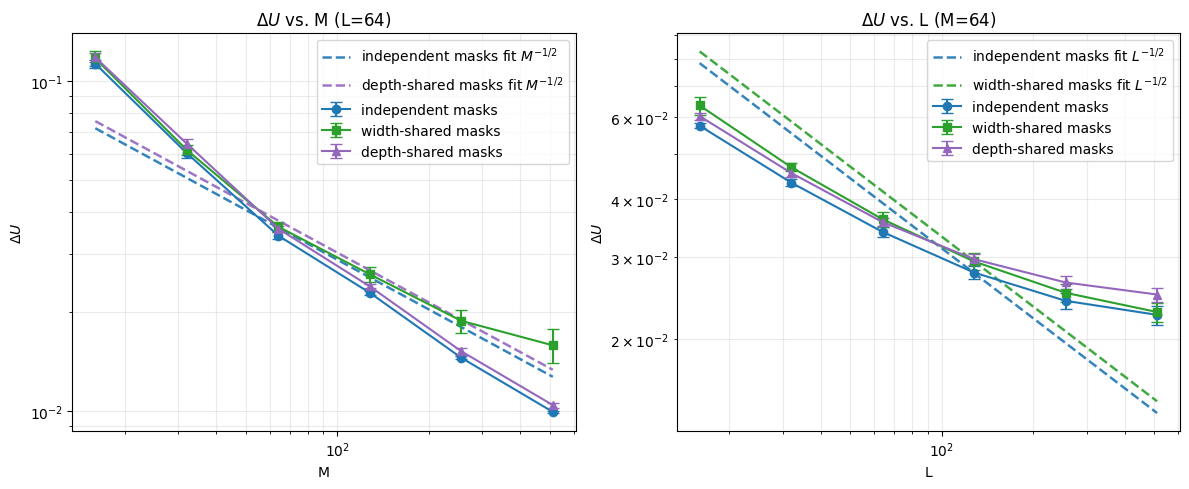

In [15]:
figU2 = plot_metric_vs_ML2(df_results, M_value=64, L_value=64, metric='Delta_U', log_x=True, log_y=True, fit_ml_inv_sqrt=[True, True, True])

In [16]:
#figU2.savefig(f"plots/{DATASET}/Delta_U_vs_M_and_L.pdf")

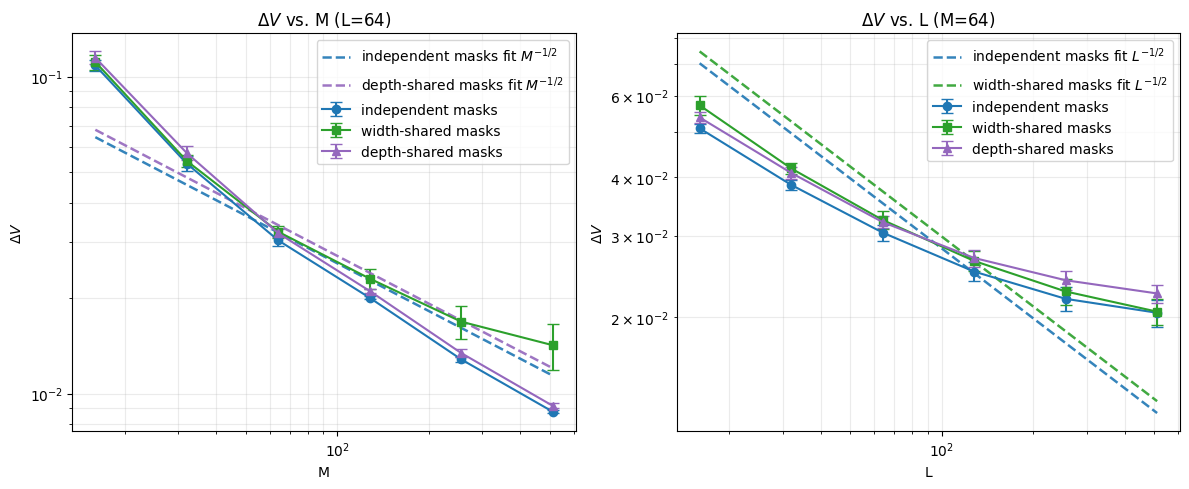

In [17]:
figV2 = plot_metric_vs_ML2(df_results, M_value=64, L_value=64, metric='Delta_V', log_x=True, log_y=True, fit_ml_inv_sqrt=[True, True, True], fit_ml_bounds=[(8, 10000000), (8, 1000000), (8, 10000000)])

In [18]:
#figV2.savefig(f"plots/{DATASET}/Delta_V_vs_M_and_L.pdf")

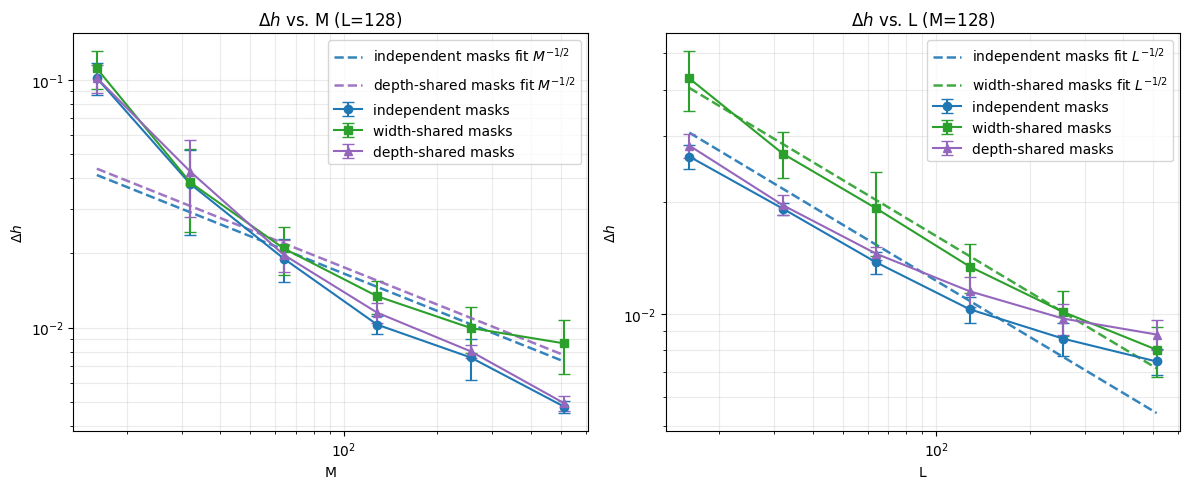

In [28]:
figh2 = plot_metric_vs_ML2(df_results, M_value=128, L_value=128, metric='Delta_h', log_x=True, log_y=True, fit_ml_inv_sqrt=[True, True, True], fit_ml_bounds=[(8, 10000000), (8, 1000000), (8, 10000000)])

In [20]:
#figh2.savefig(f"plots/{DATASET}/Delta_h_vs_M_and_L.pdf")

# Detailed Convergence Plots

In [21]:
import matplotlib.cm as cm

def plot_metric_parametrized(
    df,
    variant,
    metric='Delta_U',
    methods=None,
    target_Ms=None,
    target_Ls=None,
    log_x=False,
    log_y=False,
    fit_ml_inv_sqrt=False,
    fit_ml_bounds=None,
    fit_linestyle='--',
    fit_alpha=0.9,
    aggregate_duplicates=True,
    std_combine='quadrature',
    figsize=(14, 6),
    show=True,
):
    """Plot `metric` vs L (parametrized by M) and vs M (parametrized by L) for a fixed variant.

    Args:
        df: pandas DataFrame containing columns ['D','L','M','M*L','variant','method',metric]
        variant: string specifying the single variant/dynamic to plot (e.g., 'stochastic_depth')
        metric: string key to plot; must be one of 'Delta_U','Delta_V','Delta_h'
        methods: list of methods to include (defaults to all available for the variant in df)
        target_Ms: list of specific M values to plot in the left panel (Errors vs L). If None, plots all.
        target_Ls: list of specific L values to plot in the right panel (Errors vs M). If None, plots all.
        log_x, log_y: whether to use log scale for axes
        fit_ml_inv_sqrt: bool, or a dict mapping variant -> bool (for backwards compatibility)
        fit_ml_bounds: (lower, upper) bounds for the x-axis values to include in fit.
                       Can be tuple or a dict mapping variant -> tuple.
        fit_linestyle: linestyle used for the fit curve
        fit_alpha: alpha used for the fit curve
        aggregate_duplicates: whether to collapse duplicates using mean/std_combine
        std_combine: 'quadrature' or 'mean' for combining standard deviations
        figsize: tuple width,height for the whole figure
        show: whether to plt.show() the figure

    Returns:
        matplotlib Figure
    """
    if metric not in ('Delta_U', 'Delta_V', 'Delta_h', 'test_loss_diff', 'train_loss_diff'):
        raise ValueError("metric must be one of 'Delta_U','Delta_V','Delta_h', 'test_loss_diff', 'train_loss_diff'")

    if std_combine not in ('quadrature', 'mean'):
        raise ValueError("std_combine must be one of 'quadrature', 'mean'")

    subset = df[df['variant'] == variant].copy()
    if subset.empty:
        raise ValueError(f"No data found for variant '{variant}'")

    if methods is None:
        methods = list(subset['method'].unique())
    else:
        subset = subset[subset['method'].isin(methods)]

    # Normalize backward-compatible fit parameters for the single variant
    if isinstance(fit_ml_inv_sqrt, dict):
        should_fit_base = fit_ml_inv_sqrt.get(variant, False)
    elif isinstance(fit_ml_inv_sqrt, bool):
        should_fit_base = fit_ml_inv_sqrt
    else:
        should_fit_base = False

    if isinstance(fit_ml_bounds, dict):
        x_lower, x_upper = fit_ml_bounds.get(variant, (None, None))
    elif isinstance(fit_ml_bounds, (list, tuple)) and len(fit_ml_bounds) == 2:
        x_lower, x_upper = fit_ml_bounds
    else:
        x_lower, x_upper = (None, None)

    variant_display_map = {
        'full_unit_dropout': 'independent',
        'stochastic_depth': 'width-shared',
        'single_source_M': 'depth-shared',
    }

    metric_label_map = {
        'Delta_U': r'$\Delta U$',
        'Delta_V': r'$\Delta V$',
        'Delta_h': r'$\Delta h$',
        'test_loss_diff': r'$\Delta \mathcal{L}_{\text{test}}$',
        'train_loss_diff': r'$\Delta \mathcal{L}_{\text{train}}$',
    }
    
    markers = ['o', 's', '^', 'd', 'x', 'P', 'v']

    # Configuration for the two subplots
    # Tuple format: (x_col, param_col, x_label, param_label, target_params)
    panels = [
        ('L', 'M', 'L', 'M', target_Ms),
        ('M', 'L', 'M', 'L', target_Ls),
    ]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    def _aggregate_subset(df_series, x_col):
        """Collapse rows sharing the same x_col value into a single point."""
        std_col = metric + '_std'
        has_std = std_col in df_series.columns

        if std_combine == 'quadrature':
            std_agg = lambda s: float(np.sqrt(np.mean(np.square(np.asarray(s, dtype=float)))))
        else:
            std_agg = 'mean'

        agg_dict = {metric: 'mean'}
        if has_std:
            agg_dict[std_col] = std_agg

        grouped = df_series.groupby(x_col, as_index=False).agg(agg_dict).sort_values(x_col)
        x = np.asarray(grouped[x_col].values)
        y = np.asarray(grouped[metric].values)
        yerr = np.asarray(grouped[std_col].values) if has_std else None
        return x, y, yerr

    def _plot_panel(ax, x_col, param_col, x_label, param_label, target_params):
        has_any = False
        
        # Domain logic for fits
        should_fit = should_fit_base
        if variant == 'single_source_M' and x_col == 'L':
            should_fit = False
        if variant == 'stochastic_depth' and x_col == 'M':
            should_fit = False

        # Filter the parameters based on the new target arguments
        all_param_values = sorted(subset[param_col].dropna().unique())
        if target_params is not None:
            all_param_values = [p for p in all_param_values if p in target_params]

        if not all_param_values:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
            return

        # Create a colormap mapping specific parameter values to colors
        cmap = cm.viridis
        color_map = {
            val: cmap(i / max(1, len(all_param_values) - 1)) 
            for i, val in enumerate(all_param_values)
        }

        fit_legend_added = False

        for m_idx, method in enumerate(methods):
            df_method = subset[subset['method'] == method]
            if df_method.empty:
                continue

            marker = markers[m_idx % len(markers)]

            for p_val in all_param_values:
                df_series = df_method[df_method[param_col] == p_val].copy()
                if df_series.empty:
                    continue
                has_any = True

                if aggregate_duplicates:
                    x, y, yerr = _aggregate_subset(df_series, x_col)
                else:
                    df_series = df_series.sort_values(x_col)
                    x = np.asarray(df_series[x_col].values)
                    y = np.asarray(df_series[metric].values)
                    std_col = metric + '_std'
                    yerr = df_series[std_col].values if std_col in df_series.columns else None

                color = color_map[p_val]
                
                label_prefix = f"({method}) " if len(methods) > 1 else ""
                label = f"{label_prefix}{param_label}={p_val}"

                ax.errorbar(
                    x, y, yerr=yerr, marker=marker, color=color,
                    linestyle='-', label=label, capsize=4, markersize=6
                )

                if should_fit:
                    fit_mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
                    if x_lower is not None:
                        fit_mask &= (x >= x_lower)
                    if x_upper is not None:
                        fit_mask &= (x <= x_upper)
                    
                    if np.count_nonzero(fit_mask) >= 2:
                        x_fit = x[fit_mask]
                        y_fit = y[fit_mask]
                        log_c = np.mean(np.log(y_fit) + 0.5 * np.log(x_fit))
                        c = float(np.exp(log_c))
                        x_line = np.geomspace(x_fit.min(), x_fit.max(), 200)
                        y_line = c * x_line ** (-0.5)
                        
                        # Plot the actual fit line matching the series color (no label)
                        ax.plot(
                            x_line, y_line, color=color, linestyle=fit_linestyle,
                            alpha=fit_alpha, linewidth=1.8
                        )
                        
                        # Add a single unified gray entry to the legend
                        if not fit_legend_added:
                            ax.plot(
                                [], [], color='gray', linestyle=fit_linestyle,
                                alpha=fit_alpha, linewidth=1.8,
                                label=f"Fit: ${x_label}^{{-1/2}}$"
                            )
                            fit_legend_added = True

        if not has_any:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)

        ax.set_xlabel(x_label)
        ax.set_ylabel(metric_label_map[metric])
        ax.set_title(f'{variant_display_map[variant]}: {metric_label_map[metric]} vs {x_label} (by {param_label})')
        ax.grid(alpha=0.25, which='both')
        
        # Move legend outside if there are many series
        ax.legend(loc='upper right')

        if log_x: ax.set_xscale('log')
        if log_y: ax.set_yscale('log')

    for ax, (x_col, param_col, x_label, param_label, target_params) in zip(axes, panels):
        _plot_panel(ax, x_col, param_col, x_label, param_label, target_params)

    fig.tight_layout()
    if show:
        plt.show()
    return fig

In [22]:
df_results_plot_detailed = df_results_og[(df_results_og["M"] >= 4) & (df_results_og["L"] >= 4)]

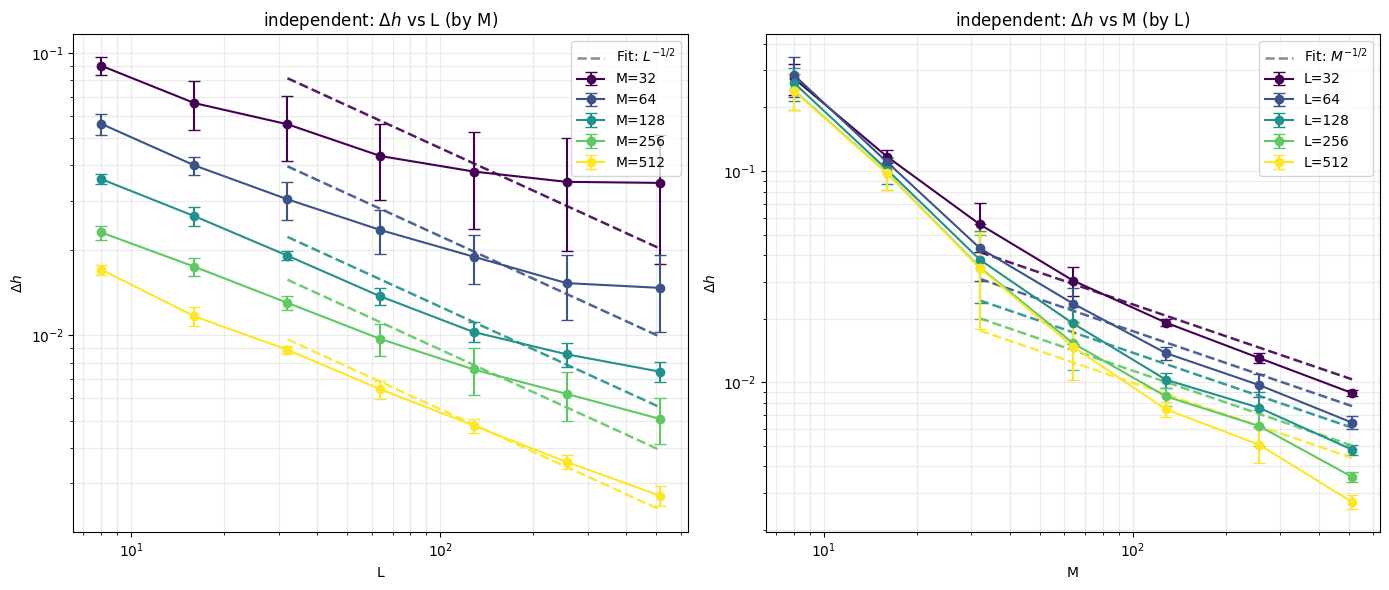

In [23]:
fig_detailed_1 = plot_metric_parametrized(
    df_results_plot_detailed,
    "full_unit_dropout", #"single_source_M",#"stochastic_depth",
    metric='Delta_h',
    target_Ms=[32, 64, 128, 256, 512],
    target_Ls=[32, 64, 128, 256, 512],
    methods=None,
    log_x=True,
    log_y=True,
    fit_ml_inv_sqrt=True,
    fit_ml_bounds=(32,10000),
    fit_linestyle='--',
    fit_alpha=0.9,
    aggregate_duplicates=True,
    std_combine='quadrature',
    figsize=(14, 6),
    show=True,
)

In [24]:
#fig_detailed_1.savefig(f"plots/{DATASET}/Delta_h_vs_M_and_L_full_unit_dropout.pdf")

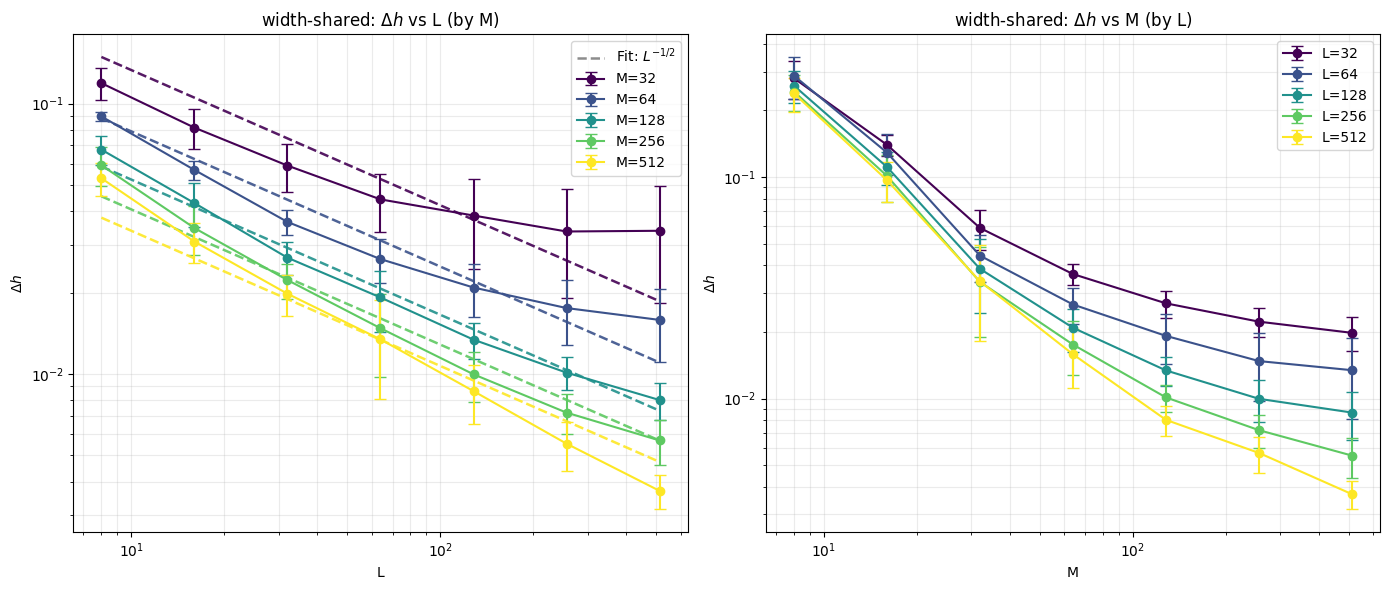

In [25]:
fig_detailed_2 = plot_metric_parametrized(
    df_results_plot_detailed,
    "stochastic_depth",#"full_unit_dropout", #"single_source_M",#"stochastic_depth",
    metric='Delta_h',
    target_Ms=[32, 64, 128, 256, 512],
    target_Ls=[32, 64, 128, 256, 512],
    methods=None,
    log_x=True,
    log_y=True,
    fit_ml_inv_sqrt=True,
    fit_ml_bounds=(4,10000),
    fit_linestyle='--',
    fit_alpha=0.9,
    aggregate_duplicates=True,
    std_combine='quadrature',
    figsize=(14, 6),
    show=True,
)

In [26]:
#fig_detailed_2.savefig(f"plots/{DATASET}/Delta_h_vs_M_and_L_stochastic_depth.pdf")

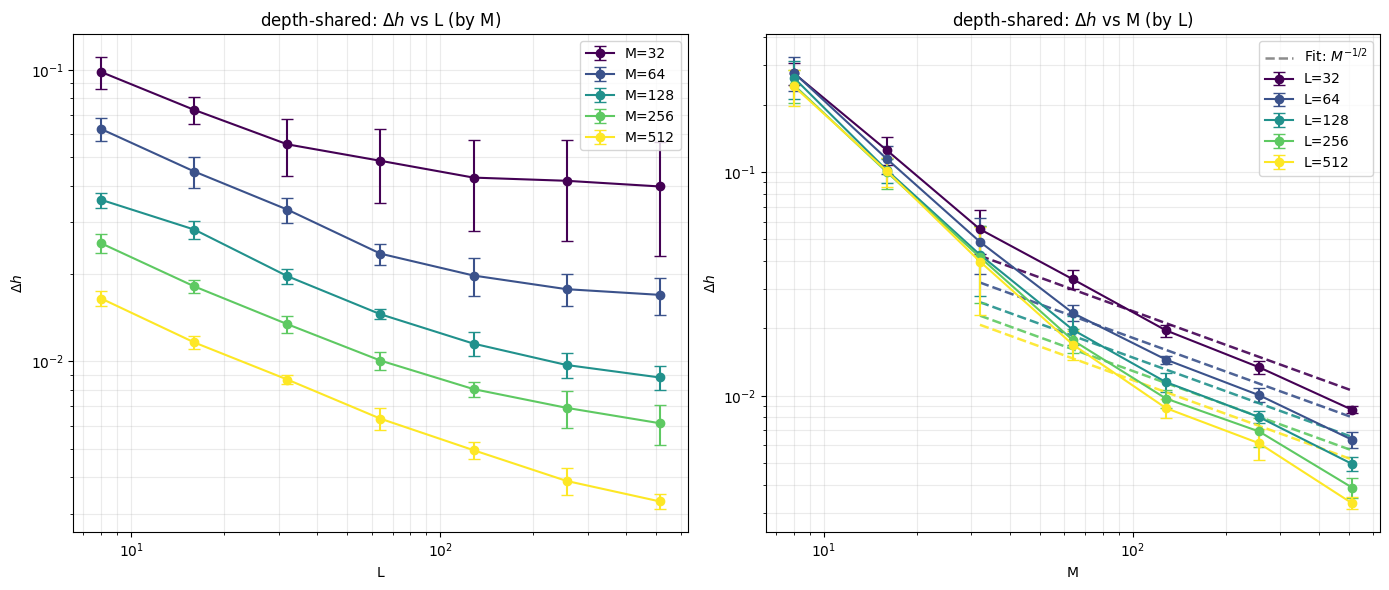

In [27]:
fig_detailed_3 = plot_metric_parametrized(
    df_results_plot_detailed,
    "single_source_M",#"full_unit_dropout", #"single_source_M",#"stochastic_depth",
    metric='Delta_h',
    target_Ms=[32, 64, 128, 256, 512],
    target_Ls=[32, 64, 128, 256, 512],
    methods=None,
    log_x=True,
    log_y=True,
    fit_ml_inv_sqrt=True,
    fit_ml_bounds=(32,10000),
    fit_linestyle='--',
    fit_alpha=0.9,
    aggregate_duplicates=True,
    std_combine='quadrature',
    figsize=(14, 6),
    show=True,
)

In [35]:
#fig_detailed_3.savefig(f"plots/{DATASET}/Delta_h_vs_M_and_L_depth_shared.pdf")